<a href="https://colab.research.google.com/github/Dripp234/AIML/blob/main/Day_5_assignment_brain_tumor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Path to your uploaded zip file
# Change this to match the exact name of the zip you upload
zip_path = "/content/archive (3).zip"
extract_path = "extracted_images"

# 2. Extract the ZIP file
print("Extracting dataset...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Extraction complete!")

X = []
y = []

# 3. Define how we map the Kaggle subfolders to our binary labels
folder_mapping = {
    'no_tumor': 0,    # Healthy
    'glioma': 1,       # Tumor
    'meningioma': 1,   # Tumor
    'pituitary': 1     # Tumor
}

# Walk through the extracted files
for root, dirs, files in os.walk(extract_path):
    # Check if the current folder matches one of our target subfolders
    folder_name = os.path.basename(root)

    if folder_name in folder_mapping:
        label = folder_mapping[folder_name]
        print(f"Processing folder '{folder_name}' as Label: {label}...")

        for file in files:
            if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
                img_path = os.path.join(root, file)

                # Load image in grayscale
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                if img is not None:
                    # Resize to keep things fast for SVM/Random Forest
                    img_resized = cv2.resize(img, (64, 64))
                    img_flattened = img_resized.flatten()

                    X.append(img_flattened)
                    y.append(label)

X = np.array(X)
y = np.array(y)

print(f"\nSuccessfully loaded {len(X)} images total!")
print(f"Total Healthy images (Label 0): {np.sum(y == 0)}")
print(f"Total Tumor images (Label 1): {np.sum(y == 1)}")

# 4. Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Extracting dataset...
Extraction complete!
Processing folder 'no_tumor' as Label: 0...
Processing folder 'meningioma' as Label: 1...
Processing folder 'pituitary' as Label: 1...
Processing folder 'glioma' as Label: 1...

Successfully loaded 10560 images total!
Total Healthy images (Label 0): 1757
Total Tumor images (Label 1): 8803

Training set size: 8448
Testing set size: 2112


In [ ]:
import numpy as np

# Check if the data needs to be scaled so we don't accidentally divide twice
if np.max(X_train) > 1.0:
    print(f"Old max value was {np.max(X_train)}. Scaling now...")
    X_train = X_train / 255.0
    X_test = X_test / 255.0
    print(f"Data successfully scaled! New max value is {np.max(X_train)}.")
else:
    print("Data is already scaled between 0 and 1!")

Old max value was 255. Scaling now...
Data successfully scaled! New max value is 1.0.


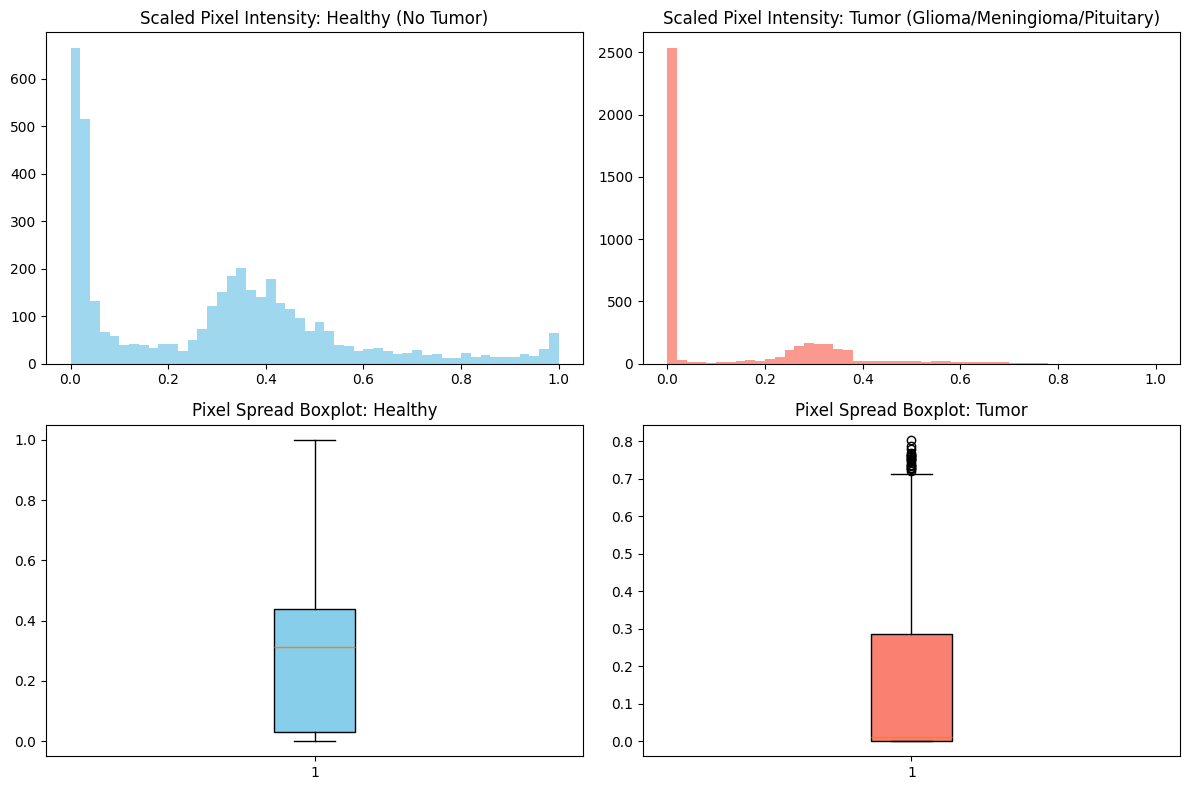

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Find the first index of a 'Healthy' (0) and 'Tumor' (1) image in the new dataset
no_tumor_idx = np.where(y_train == 0)[0][0]
yes_tumor_idx = np.where(y_train == 1)[0][0]

no_tumor_pixels = X_train[no_tumor_idx]
yes_tumor_pixels = X_train[yes_tumor_idx]

# Create standard subplots for Visualizations
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Histograms
# Notice the range is now (0, 1) because the data is scaled!
axes[0, 0].hist(no_tumor_pixels, bins=50, range=(0, 1), color='skyblue', alpha=0.8)
axes[0, 0].set_title("Scaled Pixel Intensity: Healthy (No Tumor)")

axes[0, 1].hist(yes_tumor_pixels, bins=50, range=(0, 1), color='salmon', alpha=0.8)
axes[0, 1].set_title("Scaled Pixel Intensity: Tumor (Glioma/Meningioma/Pituitary)")

# 2. Boxplots with Color Fill
bplot1 = axes[1, 0].boxplot(no_tumor_pixels, patch_artist=True)
axes[1, 0].set_title("Pixel Spread Boxplot: Healthy")

bplot2 = axes[1, 1].boxplot(yes_tumor_pixels, patch_artist=True)
axes[1, 1].set_title("Pixel Spread Boxplot: Tumor")

# Fill the 'Healthy' box with blue
for box in bplot1['boxes']:
    box.set_facecolor('skyblue')

# Fill the 'Tumor' box with red
for box in bplot2['boxes']:
    box.set_facecolor('salmon')

plt.tight_layout()
plt.show()

Training Random Forest on the massive dataset...
(This might take 1 to 2 minutes. Watch the Colab RAM wheel spin!)

Training complete! Making predictions on the Test set...

=== FINAL MODEL ACCURACY: 98.20% ===

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.94      0.95      0.95       360
       Tumor       0.99      0.99      0.99      1752

    accuracy                           0.98      2112
   macro avg       0.97      0.97      0.97      2112
weighted avg       0.98      0.98      0.98      2112



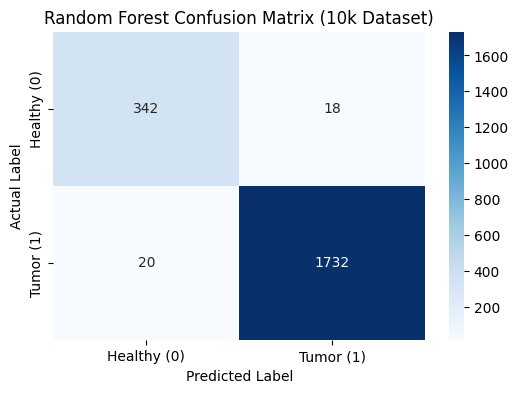

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Initialize the Random Forest
# n_jobs=-1 is a special trick that tells Colab to use ALL processor cores to speed up training!
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("Training Random Forest on the massive dataset...")
print("(This might take 1 to 2 minutes. Watch the Colab RAM wheel spin!)")

# 2. Train the model
rf_model.fit(X_train, y_train)

print("\nTraining complete! Making predictions on the Test set...")

# 3. Predict the test images
y_pred = rf_model.predict(X_test)

# 4. Evaluate the results
accuracy = accuracy_score(y_test, y_pred)
print(f"\n" + "="*40)
print(f"=== FINAL MODEL ACCURACY: {accuracy * 100:.2f}% ===")
print("="*40 + "\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Tumor']))

# 5. Plot the Confusion Matrix to see exactly where it made mistakes
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy (0)', 'Tumor (1)'],
            yticklabels=['Healthy (0)', 'Tumor (1)'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Random Forest Confusion Matrix (10k Dataset)')
plt.show()

In [ ]:
from google.colab import files
import io
import cv2
import numpy as np

print("Upload an MRI image to test the model:")
uploaded = files.upload()

for filename in uploaded.keys():
    # Read the uploaded file bytes directly into an OpenCV image
    file_bytes = np.frombuffer(uploaded[filename], dtype=np.uint8)
    img = cv2.imdecode(file_bytes, cv2.IMREAD_GRAYSCALE)

    if img is not None:
        # Match the pipeline preprocessing perfectly
        img_resized = cv2.resize(img, (64, 64))
        img_flattened = img_resized.flatten().reshape(1, -1)

        # ---> CRITICAL FIX: Scale the new image exactly like the training data! <---
        img_flattened = img_flattened / 255.0

        # Predict
        prediction = rf_model.predict(img_flattened)
        probability = rf_model.predict_proba(img_flattened)[0]

        print("\n" + "="*30)
        if prediction[0] == 1:
            print(f"RESULT: YES (Brain Tumor Detected)")
            print(f"Confidence: {probability[1]*100:.2f}%")
        else:
            print(f"RESULT: NO (No Tumor Detected)")
            print(f"Confidence: {probability[0]*100:.2f}%")
        print("="*30)
    else:
        print("Could not process uploaded image. Please ensure it's a valid image file.")

Upload an MRI image to test the model:


Saving tumour.jpg.jpeg to tumour.jpg (1).jpeg

RESULT: NO (No Tumor Detected)
Confidence: 67.00%


Training SVM Model... (This might take a few seconds)

=== SVM Model Accuracy: 82.35% ===

Classification Report:
              precision    recall  f1-score   support

    No Tumor       0.87      0.65      0.74        20
       Tumor       0.81      0.94      0.87        31

    accuracy                           0.82        51
   macro avg       0.84      0.79      0.80        51
weighted avg       0.83      0.82      0.82        51



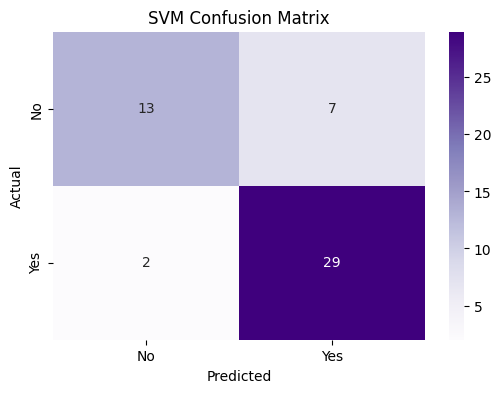

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Initialize the SVM Model
# probability=True is required if you want to draw that ROC curve later!
svm_model = SVC(kernel='rbf', probability=True, random_state=42)

print("Training SVM Model... (This might take a few seconds)")

# 2. Train the Model
svm_model.fit(X_train, y_train)

# 3. Predict on the Test Data
y_pred_svm = svm_model.predict(X_test)

# 4. Evaluate the Results
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"\n=== SVM Model Accuracy: {accuracy_svm * 100:.2f}% ===\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_svm, target_names=['No Tumor', 'Tumor']))

# 5. Plot the Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6,4))
# Changed color to 'Purples' to distinguish it from your Random Forest matrix!
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('SVM Confusion Matrix')
plt.show()

In [ ]:
from google.colab import files
import io
import cv2
import numpy as np

print("Upload an MRI image to test the SVM model:")
uploaded = files.upload()

for filename in uploaded.keys():
    # Read the uploaded file bytes directly into an OpenCV image
    file_bytes = np.frombuffer(uploaded[filename], dtype=np.uint8)
    img = cv2.imdecode(file_bytes, cv2.IMREAD_GRAYSCALE)

    if img is not None:
        # Match the pipeline preprocessing perfectly
        img_resized = cv2.resize(img, (64, 64))
        img_flattened = img_resized.flatten().reshape(1, -1)

        # Predict using the SVM model
        prediction = svm_model.predict(img_flattened)
        probability = svm_model.predict_proba(img_flattened)[0]

        print("\n" + "="*30)
        if prediction[0] == 1:
            print(f"RESULT: YES (Brain Tumor Detected)")
            print(f"Confidence: {probability[1]*100:.2f}%")
        else:
            print(f"RESULT: NO (No Tumor Detected)")
            print(f"Confidence: {probability[0]*100:.2f}%")
        print("="*30)
    else:
        print("Could not process uploaded image. Please ensure it's a valid image file.")

Upload an MRI image to test the SVM model:


Saving Image12.jpg to Image12.jpg

RESULT: NO (No Tumor Detected)
Confidence: 87.71%
